<a href="https://colab.research.google.com/github/mohity24k/Audio-Processing-for-Machine-Learning/blob/main/audio_processing_draft_00.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import librosa
import librosa.display
from glob import glob # file handling
import IPython.display as ipd # interactive audio playback
from itertools import cycle



In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
sns.set_theme(style='white', palette=None)
color_pal = plt.rcParams["axes.prop_cycle"].by_key()["color"]
color_cycle = cycle(color_pal)

In [ ]:
audio_dir=glob("/content/drive/MyDrive/Hindi_fem_mono/Hindi_fem_audio/*.wav")
audio_file = sorted(audio_dir)

In [ ]:
ipd.Audio(audio_file[2])

In [ ]:
# load the audio cell file
# y will contain the raw audio time series data
# sr will be the sample rate

y,sr = librosa.load(audio_file[2])

In [ ]:
# display the first 10 samples of the raw audio data
print(f'the first 10 samples of y is {y[:10]}')
# Display the shape of the audio data array
print(f"Shape of y (audio data): {y.shape}")

# Display the sample rate of the audio
print(f"Sample rate: {sr} Hz")

the first 10 samples of y is [-1.4012909e-05  8.9582920e-07 -9.1765742e-06 -2.4880851e-06
  1.5019210e-05  1.0491634e-05 -4.4989625e-05 -5.4112879e-06
 -1.2322516e-06  3.0269127e-06]
Shape of y (audio data): (89011,)
Sample rate: 22050 Hz


<Axes: title={'center': 'Raw Audio Waveform'}, xlabel='Sample Index', ylabel='Amplitude'>

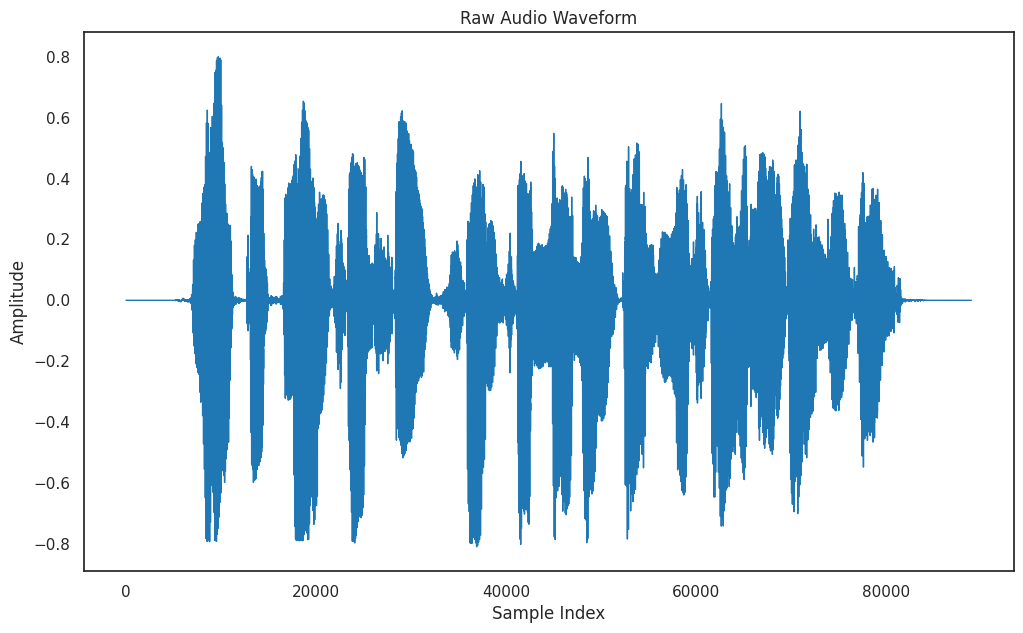

In [ ]:
# Plot the raw audio waveform
pd.Series(y).plot(
    figsize=(12, 7),             # Set the figure size for better visibility
    lw=1,                       # Line width for the waveform
    title="Raw Audio Waveform", # Title of the plot
    color=color_pal[0],         # Set the color using the predefined palette
    xlabel="Sample Index",      # Label for the x-axis
    ylabel="Amplitude"          # Label for the y-axis
)

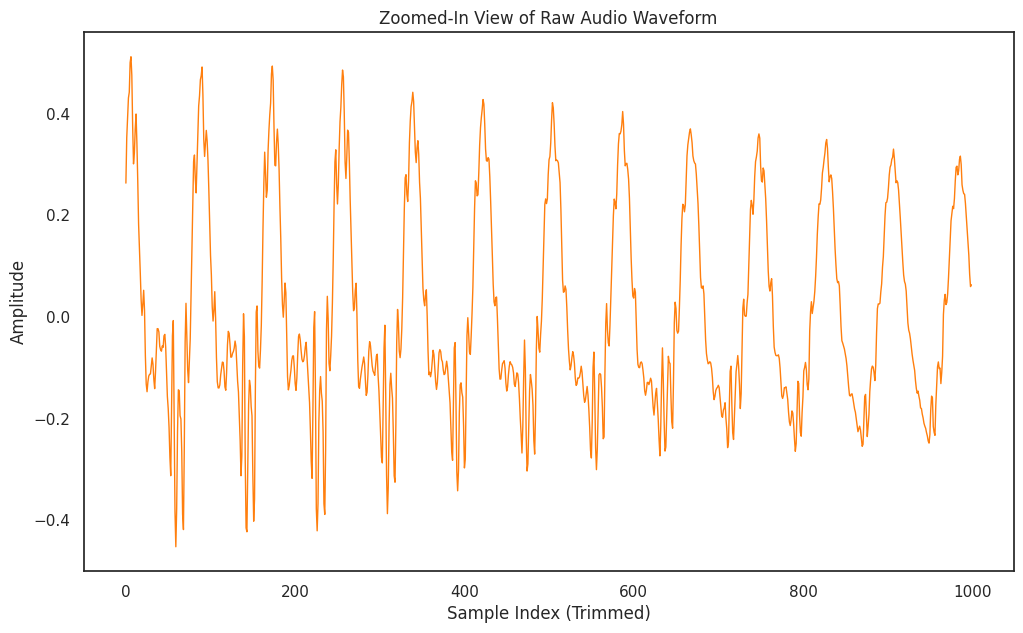

In [ ]:
# Plot a trimmed section of the raw audio waveform
pd.Series(y[30000:31000]).plot(
    figsize=(12, 7),               # Set figure size for better visibility
    lw=1,                         # Line width for the waveform
    title="Zoomed-In View of Raw Audio Waveform",  # Descriptive title for clarity
    color=color_pal[1],           # Use a consistent color palette for aesthetics
    xlabel="Sample Index (Trimmed)", # X-axis label indicating the zoomed-in range
    ylabel="Amplitude"            # Y-axis label for amplitude values
)

# Display the plot
plt.show()



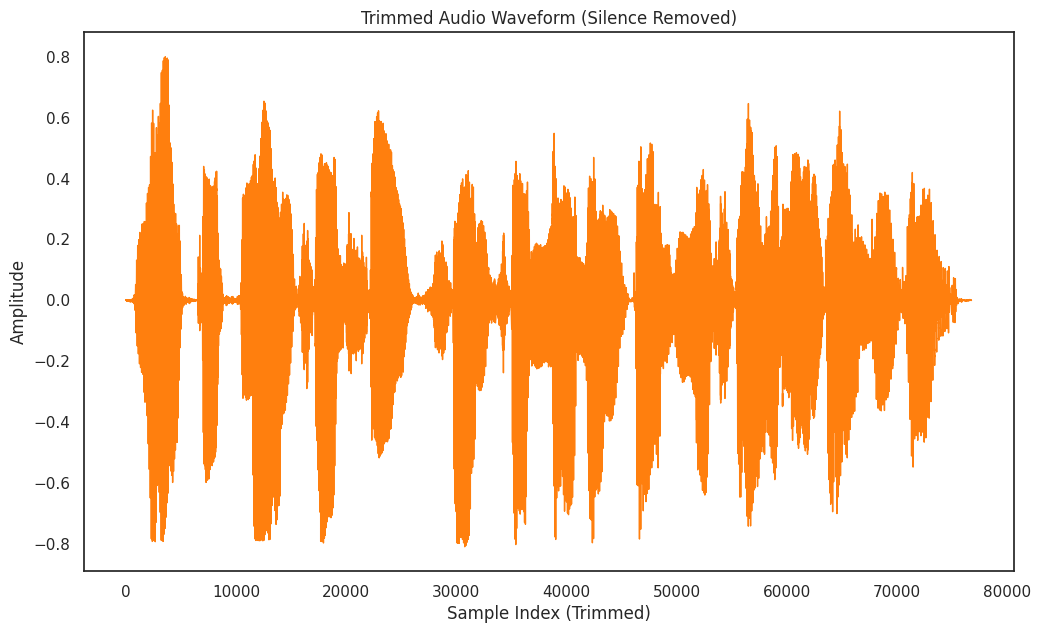

In [ ]:
# Trim the audio signal to remove silence
# `y_trim`: Audio data after silence trimming
# `top_db`: Threshold in decibels for considering a region as silence
y_trim, _ = librosa.effects.trim(y, top_db=35)

# Plot the trimmed audio waveform
pd.Series(y_trim).plot(
    figsize=(12, 7),                # Set figure size for clear visualization
    lw=1,                          # Line width for the waveform
    title="Trimmed Audio Waveform (Silence Removed)",  # Descriptive title
    color=color_pal[1],            # Use a specific color from the palette
    xlabel="Sample Index (Trimmed)", # Label the x-axis for context
    ylabel="Amplitude"             # Label the y-axis to indicate amplitude values
)

# Show the plot
plt.show()

In [ ]:
# Compute the Short-Time Fourier Transform (STFT) of the audio signal
D = librosa.stft(y)  # D is the complex-valued STFT matrix

# Convert the STFT magnitudes to decibels (log scale)
S_db = librosa.amplitude_to_db(np.abs(D), ref=np.max)
# np.abs(D) ensures we take the magnitude of the STFT, discarding phase information.
# ref=np.max normalizes the values relative to the maximum magnitude in the spectrogram.

# Display the shape of the resulting spectrogram
print(f"Spectrogram Shape: {S_db.shape}")  # (n_freq_bins, n_time_frames)



Spectrogram Shape: (1025, 174)


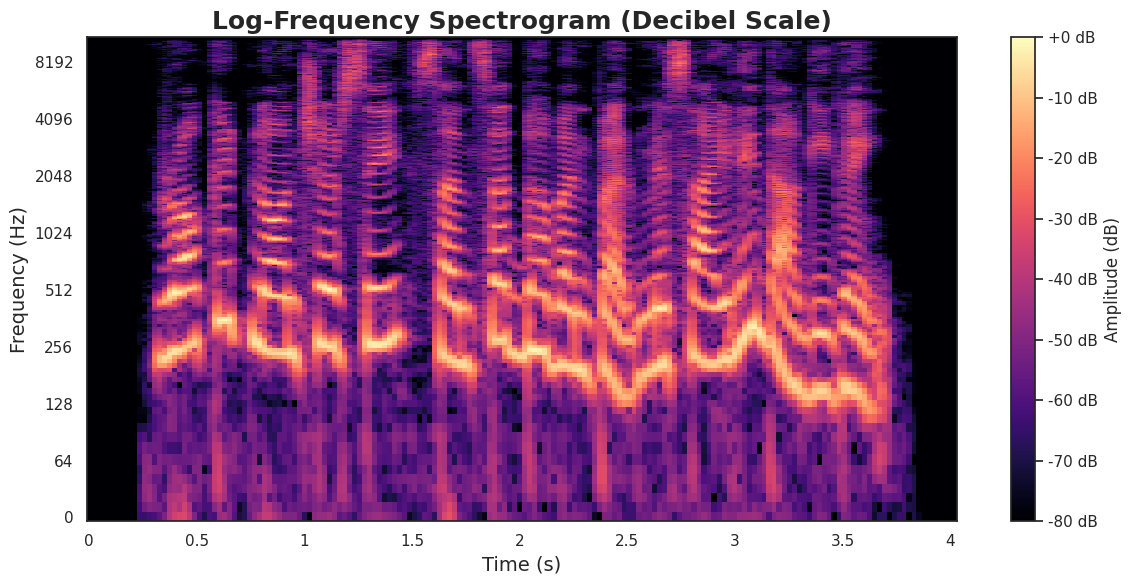

In [ ]:
# Plot the Log-Frequency Spectrogram
fig, ax = plt.subplots(figsize=(12, 6))  # Larger figure for better visibility

# Display the spectrogram with log-scaled frequency axis
img = librosa.display.specshow(
    S_db,                 # Spectrogram data (in decibels)
    x_axis='time',        # X-axis: Time in seconds
    y_axis='log',         # Y-axis: Logarithmic frequency scale
    sr=sr,                # Sample rate (ensures correct time and frequency scaling)
    cmap='magma',         # Colormap for improved aesthetics
    ax=ax                 # Subplot to plot on
)

# Add descriptive title and labels
ax.set_title("Log-Frequency Spectrogram (Decibel Scale)", fontsize=18, fontweight='bold')
ax.set_xlabel("Time (s)", fontsize=14)
ax.set_ylabel("Frequency (Hz)", fontsize=14)

# Add a color bar to indicate decibel levels
cbar = fig.colorbar(img, ax=ax, format="%+2.0f dB")
cbar.set_label("Amplitude (dB)", fontsize=12)

# Show the plot
plt.tight_layout()  # Adjust layout to prevent clipping
plt.show()